In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Загрузим полный набор данных

In [2]:
train_part1 = pl.scan_parquet("../ClearData_for_part_4/train_full.parquet")
# train_part1.shape

In [3]:
train_part1.schema

/tmp/ipykernel_102748/896344679.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  train_part1.schema


Schema([('event_dttm', String),
        ('event_type_nm', Int16),
        ('event_desc', Int16),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('timezone', Int16),
        ('session_id', Float64),
        ('operating_system_type', Int16),
        ('battery', String),
        ('device_system_version', String),
        ('screen_size', String),
        ('developer_tools', Int16),
        ('phone_voip_call_state', Int16),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [4]:
pos_class = train_part1.filter(pl.col("target") == 1).collect()
pos_class.shape

(51438, 21)

In [5]:
train_part1 = train_part1.filter(pl.col("target") != 1).collect()
train_part1.shape

(85626402, 21)

In [6]:
neg_class = 13_000_000
train_part1 = train_part1.sample(n=neg_class)

# columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
#            "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

# for i in columns:
#     train_part1 = train_part1.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

In [7]:
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1.0, shuffle=True)
train_part1.shape

(13051438, 21)

In [8]:
train_part1 = train_part1.sort("event_dttm")
train_part1 = train_part1.drop("event_dttm")

In [9]:
x = train_part1.drop("target")
y = train_part1["target"]

In [10]:
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)   
X_train = x[:int(0.9*len(x))]
X_test = x[int(0.9*len(x)):]
y_train = y[:int(0.9*len(y))]
y_test = y[int(0.9*len(y)):]

In [11]:
# cat_features = ["event_type_nm", "event_desc", "channel_indicator_type", "channel_indicator_sub_type", \
#                 "currency_iso_cd", "mcc_code", "pos_cd", "timezone", "operating_system_type", "battery",\
#                 "device_system_version", "screen_size", \
#                 "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised"]

# cat_features = [
#     'mcc_code', 'event_desc', 'channel_indicator_type',
#     'timezone', 'operating_system_type', 'device_system_version',
#     'screen_size', 'battery'
# ]

columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
           "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

for i in columns:
    X_train = X_train.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

for i in columns:
    X_test = X_test.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery'
]

for i in cat_features:
    X_train = X_train.with_columns(pl.col(i).fill_null('missing'))

for i in cat_features:
    X_test = X_test.with_columns(pl.col(i).fill_null('missing'))

In [12]:
del train_part1, x, y
gc.collect()

0

In [13]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

-------------------------------------------------------------

In [14]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.05,
    border_count=128,
    l2_leaf_reg=5,
    one_hot_max_size=10,
    class_weights=weights,
    cat_features=cat_features, 
    verbose=False)

Train metrics:
Accuracy: 0.9529174052684192
Precision: 0.025129933926817012
Recall: 0.2882117667297437
F1-score: 0.04622903775446148
PR-AUC: 0.029399514001028828

Test metrics:
Accuracy: 0.9604480425148489
Precision: 0.02756471231102386
Recall: 0.2760437778678557
F1-score: 0.05012420645873585
PR-AUC: 0.03645644197408346

Confusion matrix


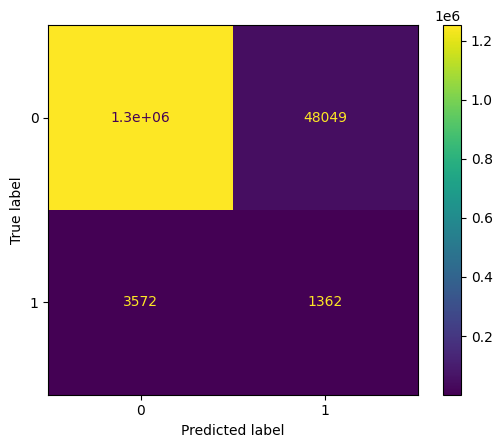

In [15]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

-------------------------------------------------------------

In [16]:
CatBoost = CatBoostClassifier(iterations=15, depth=4, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.7953642229625787
Precision: 0.010966089725343622
Recall: 0.5683167039394461
F1-score: 0.021516993205974184
PR-AUC: 0.02647893340052533

Test metrics:
Accuracy: 0.8607050256523419
Precision: 0.013831927783702954
Recall: 0.5099310903931901
F1-score: 0.026933287659501585
PR-AUC: 0.030998484513942614

Confusion matrix


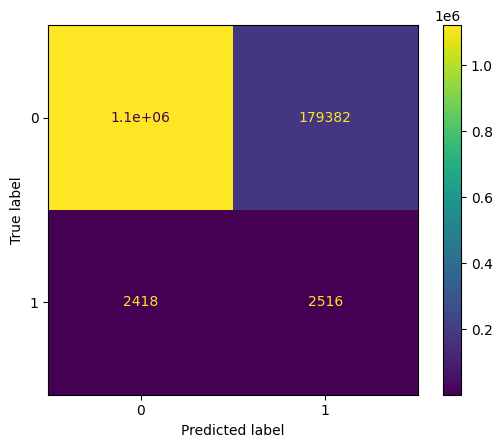

In [17]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [18]:
CatBoost = CatBoostClassifier(iterations=15, depth=5, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.7960478428345145
Precision: 0.01122088561978904
Recall: 0.5798425941854464
F1-score: 0.022015731470943153
PR-AUC: 0.029138886760362748

Test metrics:
Accuracy: 0.8576808382829787
Precision: 0.014181233912440687
Recall: 0.5348601540332387
F1-score: 0.027629891375474416
PR-AUC: 0.03670901815200708

Confusion matrix


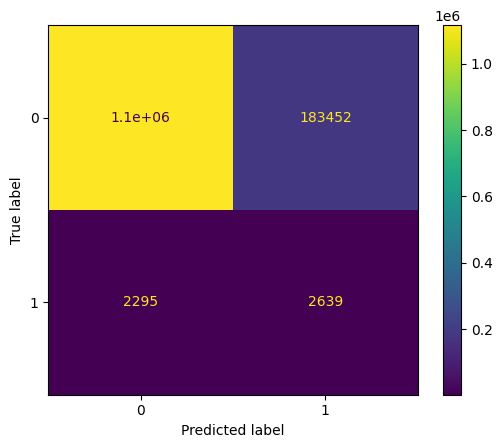

In [19]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [20]:
CatBoost = CatBoostClassifier(iterations=15, depth=6, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.7673613481835206
Precision: 0.010439888897799097
Recall: 0.6158825047307759
F1-score: 0.020531742083296892
PR-AUC: 0.02965310461564975

Test metrics:
Accuracy: 0.8599449562653623
Precision: 0.014494889937106918
Recall: 0.5381029590595865
F1-score: 0.02822936491903329
PR-AUC: 0.034641464092474476

Confusion matrix


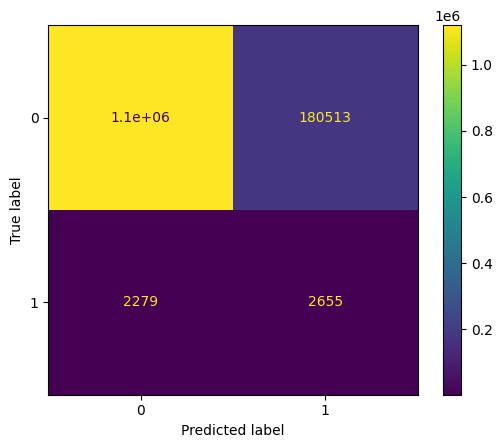

In [21]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [22]:
CatBoost = CatBoostClassifier(iterations=50, depth=5, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.7583471859294515
Precision: 0.010609115292403595
Recall: 0.650761224840874
F1-score: 0.02087786658461683
PR-AUC: 0.03409132387695298

Test metrics:
Accuracy: 0.86353919567496
Precision: 0.015342935029023392
Recall: 0.555533036076206
F1-score: 0.029861152721112522
PR-AUC: 0.04138180112752117

Confusion matrix


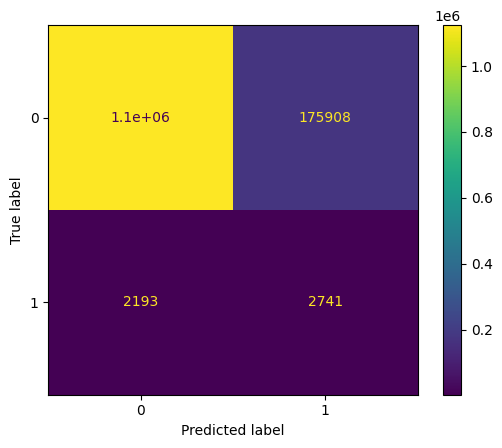

In [23]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

Попробуем настроить веса меток самостоятельно

In [24]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9427109520670945
Precision: 0.026631019598834467
Recall: 0.3789136418372613
F1-score: 0.04976446533065227
PR-AUC: 0.037225299823953624

Test metrics:
Accuracy: 0.9527837541298125
Precision: 0.029324831456942646
Recall: 0.3579246047831374
F1-score: 0.054208361470931304
PR-AUC: 0.043121121099610485

Confusion matrix


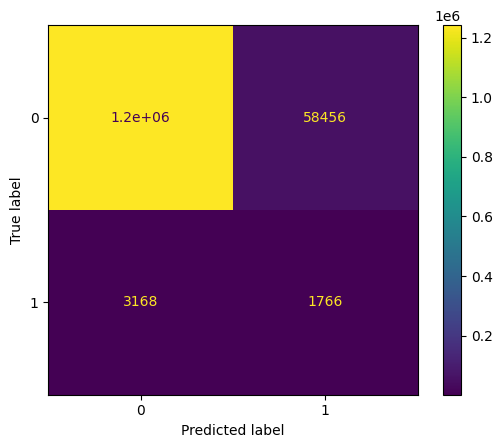

In [25]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [26]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9445378261432925
Precision: 0.027451317341415215
Recall: 0.37785996903492175
F1-score: 0.051184135597762366
PR-AUC: 0.03798694735294696

Test metrics:
Accuracy: 0.9535514855065801
Precision: 0.030344432075026146
Recall: 0.3646128901499797
F1-score: 0.05602616007474307
PR-AUC: 0.04269642076460057

Confusion matrix


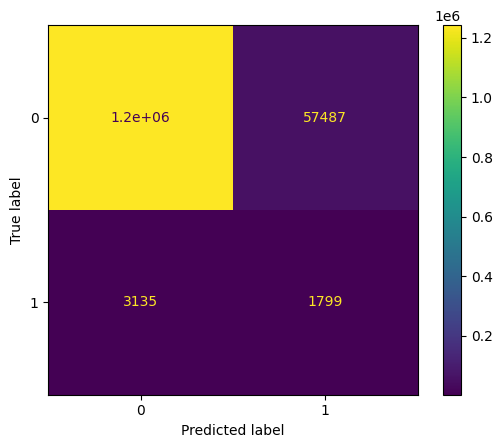

In [27]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [28]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9411827253770423
Precision: 0.026795169114763633
Recall: 0.39231033889557887
F1-score: 0.05016408362696993
PR-AUC: 0.039833196510838095

Test metrics:
Accuracy: 0.9509333835959863
Precision: 0.030278947786696337
Recall: 0.38609647344953385
F1-score: 0.0561541069138823
PR-AUC: 0.04428433979709631

Confusion matrix


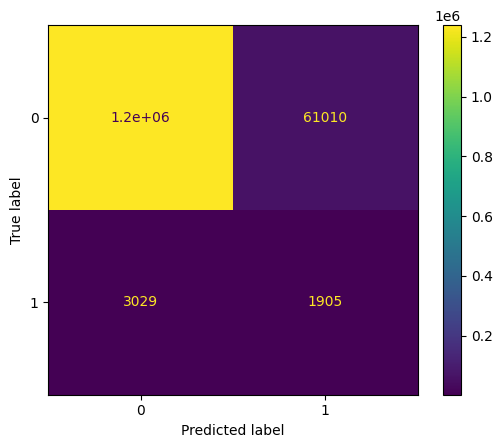

In [29]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [30]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=50, depth=4, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.39142558495470997
Precision: 0.0057350680558254305
Recall: 0.8860098056081197
F1-score: 0.011396368363550872
PR-AUC: 0.032425814730936774

Test metrics:
Accuracy: 0.4441272380672171
Precision: 0.005684328376639235
Recall: 0.8396838265099311
F1-score: 0.01129221292485486
PR-AUC: 0.03981525828306816

Confusion matrix


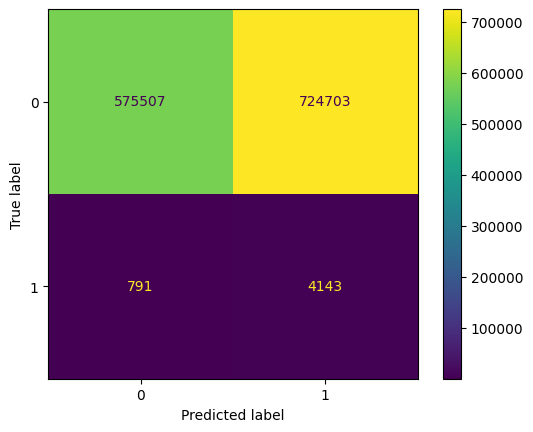

In [31]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [32]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.4166836791246669
Precision: 0.005945094306227314
Recall: 0.8804618957509032
F1-score: 0.011810441618790558
PR-AUC: 0.032304255295056795

Test metrics:
Accuracy: 0.4674717885536002
Precision: 0.005885621326856763
Recall: 0.8329955411430888
F1-score: 0.01168865517898431
PR-AUC: 0.03864591439157935

Confusion matrix


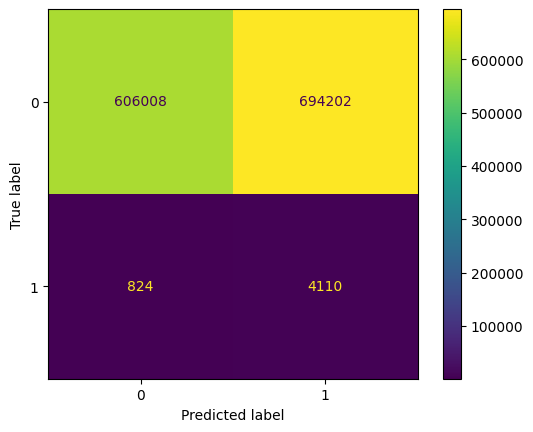

In [33]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [34]:
weights = {0: 1, 1: 800}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.22181276920192872
Precision: 0.00482342284538062
Recall: 0.9524557027352486
F1-score: 0.009598238325733347
PR-AUC: 0.03299856468001558

Test metrics:
Accuracy: 0.24526029311708133
Precision: 0.004679745696756522
Recall: 0.938386704499392
F1-score: 0.009313047116374871
PR-AUC: 0.03849597848647216

Confusion matrix


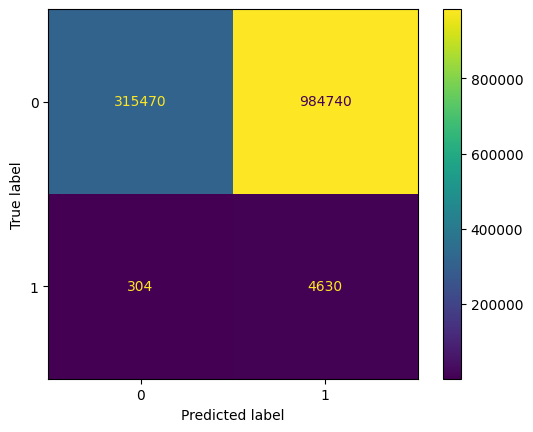

In [35]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [36]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.13291860394435895
Precision: 0.004442111727517113
Recall: 0.9771202477206262
F1-score: 0.00884401743773984
PR-AUC: 0.03234198073853649

Test metrics:
Accuracy: 0.15647698644747246
Precision: 0.004322762660520668
Recall: 0.9685853263072558
F1-score: 0.008607112078863407
PR-AUC: 0.037783285806194326

Confusion matrix


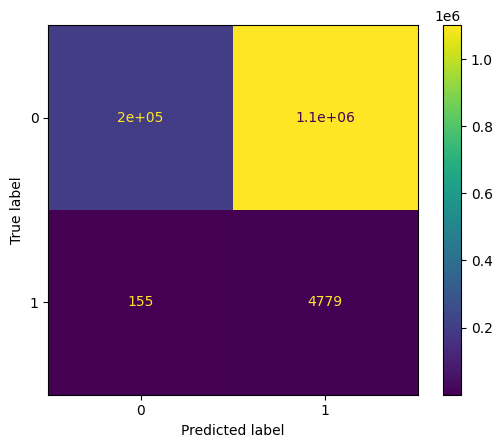

In [37]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [38]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=50, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.1398548342140934
Precision: 0.004472990982475406
Recall: 0.9760665749182866
F1-score: 0.008905172498356925
PR-AUC: 0.03301510038857829

Test metrics:
Accuracy: 0.1596229994544663
Precision: 0.004337077243917696
Recall: 0.9681799756789623
F1-score: 0.008635470869973527
PR-AUC: 0.03779394926777261

Confusion matrix


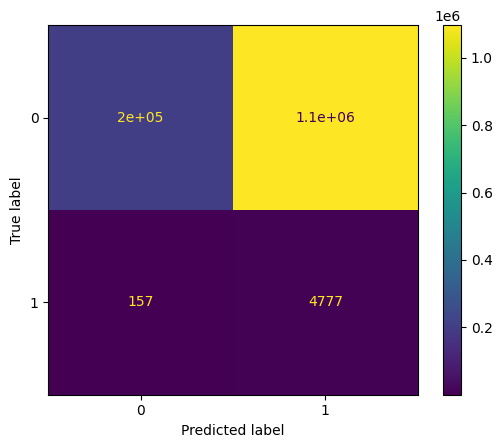

In [39]:
train_models(CatBoost, X_train, X_test, y_train, y_test)